# Impact comparison
<!-- markdownlint-disable MD013 -->

Check that:

- rainfall is good predictor of flood extent
- flood extent is good predictor of impact
- CERF/CBPF allocations are well-matched with impact

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [184]:
import calendar

import ocha_stratus as stratus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.constants import *
from src.datasources import era5, seas5

## Load data

### Exposure

In [3]:
pcode = "SS"
query = f"SELECT * FROM app.floodscan_exposure WHERE pcode = '{pcode}'"

In [4]:
df_exp_daily = pd.read_sql(
    query, stratus.get_engine(stage="prod"), parse_dates=["valid_date"]
)

In [100]:
df_exp_yearly = (
    df_exp_daily.groupby(df_exp_daily["valid_date"].dt.year)["sum"]
    .agg(["mean", "max", "min"])
    .reset_index()
)
df_exp_yearly["max_diff"] = df_exp_yearly["max"] - df_exp_yearly["min"]
df_exp_yearly["mean_diff"] = df_exp_yearly["mean"] - df_exp_yearly["min"]

<Axes: xlabel='valid_date'>

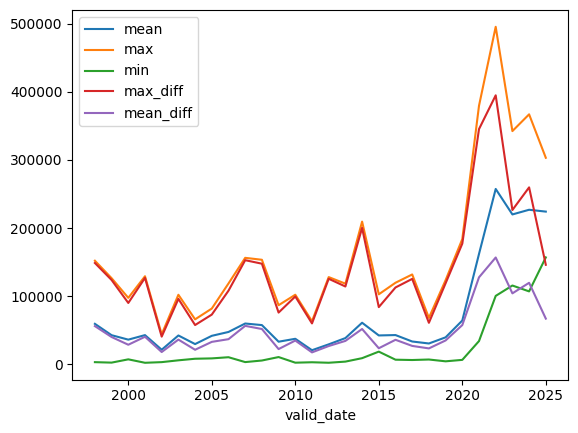

In [101]:
df_exp_yearly.set_index("valid_date").plot()

In [106]:
df_exp_yearly = df_exp_yearly.rename(
    columns={
        x: f"{x}_exp"
        for x in df_exp_yearly.columns
        if x != "valid_date" and "exp" not in x
    }
)

In [107]:
df_exp_yearly

,valid_date,mean_exp,max_exp,min_exp,max_diff_exp,mean_diff_exp
0,1998,59556.785311,152155.0,3343.0,148812.0,56213.785311
1,1999,42893.224658,126544.0,2663.0,123881.0,40230.224658
2,2000,36362.508197,97660.0,7472.0,90188.0,28890.508197
3,2001,43013.652055,129377.0,2423.0,126954.0,40590.652055
4,2002,21579.810959,44173.0,3374.0,40799.0,18205.810959
5,2003,42480.830137,102194.0,6037.0,96157.0,36443.830137
6,2004,29861.836066,66140.0,8338.0,57802.0,21523.836066
7,2005,41970.375342,81974.0,8870.0,73104.0,33100.375342
8,2006,47637.558904,118770.0,10580.0,108190.0,37057.558904
9,2007,60032.915068,156370.0,3439.0,152931.0,56593.915068


### SEAS5

Load and filter SEAS5 data to specific `issued_month`.

In [13]:
df_seas5_all = seas5.load_seas5(pcode=pcode)

In [227]:
issued_month = 4
issued_mo_str = calendar.month_abbr[issued_month]
df_seas5_imo = df_seas5_all[
    df_seas5_all["issued_date"].dt.month == issued_month
]

In [228]:
valid_months = sorted(df_seas5_imo["valid_date"].dt.month.unique())
valid_mo_str = "".join([calendar.month_abbr[x][0] for x in valid_months])
valid_mo_str

'AMJJASO'

In [229]:
df_seas5_yearly = (
    df_seas5_imo.groupby(df_seas5_imo["valid_date"].dt.year)["mean"]
    .mean()
    .reset_index()
)

In [230]:
def detrend_column(
    df: pd.DataFrame, col: str, index_col: str = "valid_date"
) -> pd.DataFrame:
    """
    Detrend a column in a DataFrame using linear regression (via NumPy).

    Parameters:
    -----------
    df : pd.DataFrame
        The input DataFrame. Must contain a datetime column.
    col : str
        The name of the column to detrend.
    time_col : str
        The name of the datetime column. Default is "valid_date".

    Returns:
    --------
    pd.DataFrame
        Copy of the input DataFrame with a new column: <col>_detrended
    """
    df_sorted = df.sort_values(index_col).copy()

    # Convert datetime to numeric (days since min)
    x = df_sorted[index_col]
    y = df_sorted[col].values

    # Linear regression fit
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]

    trend = a * x + b
    detrended = y - trend
    detrended += y.mean()  # Shift to preserve original mean

    df_sorted[f"{col}_detrended"] = detrended

    return df_sorted

In [231]:
df_seas5_yearly = detrend_column(df_seas5_yearly, col="mean")

<Axes: xlabel='valid_date'>

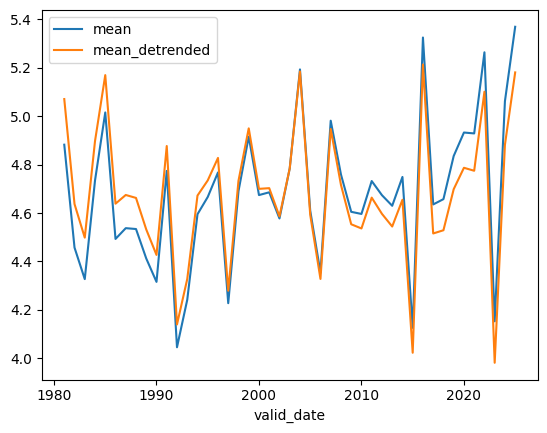

In [232]:
df_seas5_yearly.set_index("valid_date").plot()

In [233]:
df_seas5_yearly

,valid_date,mean,mean_detrended
0,1981,4.881939,5.070289
1,1982,4.457162,4.636950
2,1983,4.326990,4.498217
3,1984,4.734103,4.896769
4,1985,5.015047,5.169152
5,1986,4.492831,4.638374
6,1987,4.537360,4.674342
7,1988,4.533793,4.662213
8,1989,4.412129,4.531988
9,1990,4.315574,4.426872


### ERA5

Load and filter ERA5 data to same `valid_month`

In [234]:
df_era5 = era5.load_era5(pcode=pcode)

In [235]:
df_era5_yearly = (
    df_era5[df_era5["valid_date"].dt.month.isin(valid_months)]
    .groupby(df_era5["valid_date"].dt.year)["mean"]
    .mean()
    .reset_index()
)
df_era5_yearly = df_era5_yearly[df_era5_yearly["valid_date"] < 2025]

In [236]:
df_era5_yearly = detrend_column(df_era5_yearly, "mean")

<Axes: xlabel='valid_date'>

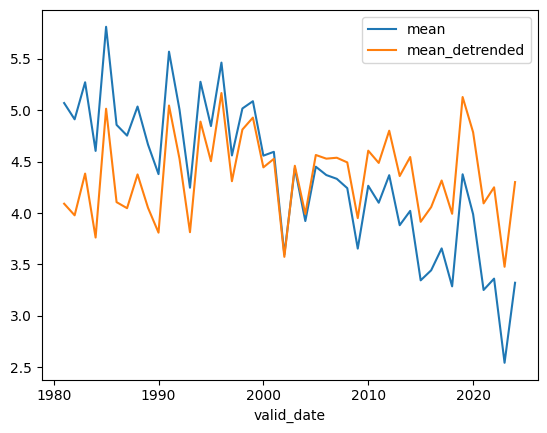

In [237]:
df_era5_yearly.set_index("valid_date").plot()

### EM-DAT

In [238]:
blob_name = f"{PROJECT_PREFIX}/raw/emdat/emdat_ssd_flooding_2025-04-17.csv"
df_emdat_events = stratus.load_csv_from_blob(blob_name)

In [239]:
df_emdat_yearly = (
    df_emdat_events.groupby("Start Year")["Total Affected"].sum().reset_index()
)

<Axes: xlabel='Start Year'>

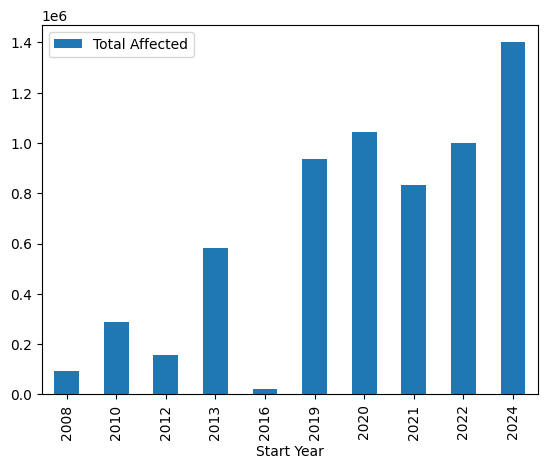

In [240]:
df_emdat_yearly.plot(x="Start Year", y="Total Affected", kind="bar")

## Combine

In [241]:
df_compare = (
    df_exp_yearly.merge(
        df_era5_yearly.rename(
            columns={
                "mean": "mean_era5",
                "mean_detrended": "mean_era5_detrended",
            }
        )
    )
    .merge(df_seas5_yearly)
    .rename(
        columns={
            "mean": "mean_seas5",
            "mean_detrended": "mean_seas5_detrended",
        }
    )
    .merge(
        df_emdat_yearly.rename(
            columns={
                "Start Year": "valid_date",
                "Total Affected": "total_affected",
            }
        ),
        how="left",
    )
).rename(columns={"valid_date": "year"})
df_compare = df_compare[
    (df_compare["year"] < 2025) & (df_compare["year"] >= 2006)
]
df_compare["cerf"] = df_compare["year"].isin(CERF_YEARS)
df_compare = df_compare.fillna(0)
df_compare

,year,mean_exp,max_exp,min_exp,max_diff_exp,mean_diff_exp,mean_era5,mean_era5_detrended,mean_seas5,mean_seas5_detrended,total_affected,cerf
8,2006,47637.558904,118770.0,10580.0,108190.0,37057.558904,4.369282,4.528714,4.353419,4.327735,0.0,False
9,2007,60032.915068,156370.0,3439.0,152931.0,56593.915068,4.332578,4.537562,4.980929,4.946684,0.0,False
10,2008,57716.191257,153533.0,5749.0,147784.0,51967.191257,4.241685,4.492222,4.758863,4.716056,92791.0,False
11,2009,33345.947945,86897.0,10816.0,76081.0,22529.947945,3.653909,3.949998,4.604791,4.553423,0.0,False
12,2010,37617.939726,102253.0,2566.0,99687.0,35051.939726,4.264810,4.606451,4.596033,4.536104,290000.0,False
13,2011,20859.567123,63358.0,3191.0,60167.0,17668.567123,4.099951,4.487144,4.731889,4.663398,0.0,False
14,2012,29456.213115,128129.0,2472.0,125657.0,26984.213115,4.367782,4.800528,4.673463,4.596411,157000.0,False
15,2013,38668.087671,118482.0,4144.0,114338.0,34524.087671,3.881315,4.359612,4.629734,4.544121,581000.0,False
16,2014,61178.600000,209511.0,9182.0,200329.0,51996.600000,4.020767,4.544616,4.748798,4.654623,0.0,False
17,2015,42527.660274,102875.0,18784.0,84091.0,23743.660274,3.345018,3.914420,4.125728,4.022992,0.0,False


In [242]:
df_compare.set_index("year").corr()

,mean_exp,max_exp,min_exp,max_diff_exp,mean_diff_exp,mean_era5,mean_era5_detrended,mean_seas5,mean_seas5_detrended,total_affected,cerf
mean_exp,1.000000,0.962105,0.953173,0.882175,0.959863,-0.626212,-0.386102,0.243447,0.142713,0.557683,0.575607
max_exp,0.962105,1.000000,0.847691,0.975835,0.987815,-0.525394,-0.261376,0.347764,0.252551,0.596317,0.644153
min_exp,0.953173,0.847691,1.000000,0.711288,0.830094,-0.700796,-0.491478,0.067270,-0.037151,0.439211,0.426857
max_diff_exp,0.882175,0.975835,0.711288,1.000000,0.966938,-0.407487,-0.143883,0.433079,0.349933,0.609208,0.677680
mean_diff_exp,0.959863,0.987815,0.830094,0.966938,1.000000,-0.504714,-0.256110,0.386493,0.297594,0.620952,0.665458
mean_era5,-0.626212,-0.525394,-0.700796,-0.407487,-0.504714,1.000000,0.879080,0.099216,0.212146,-0.090739,-0.142009
mean_era5_detrended,-0.386102,-0.261376,-0.491478,-0.143883,-0.256110,0.879080,1.000000,0.299079,0.351239,0.300536,0.262862
mean_seas5,0.243447,0.347764,0.067270,0.433079,0.386493,0.099216,0.299079,1.000000,0.988456,0.502353,0.519033
mean_seas5_detrended,0.142713,0.252551,-0.037151,0.349933,0.297594,0.212146,0.351239,0.988456,1.000000,0.417438,0.427192
total_affected,0.557683,0.596317,0.439211,0.609208,0.620952,-0.090739,0.300536,0.502353,0.417438,1.000000,0.928206


<Axes: >

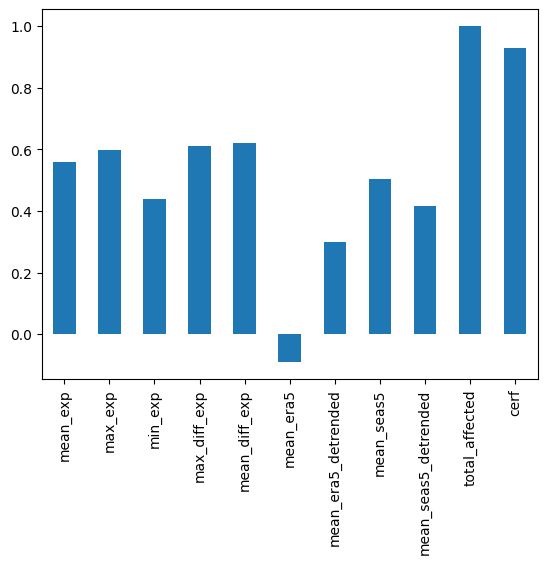

In [243]:
df_compare.set_index("year").corr()["total_affected"].plot(kind="bar")

<Axes: >

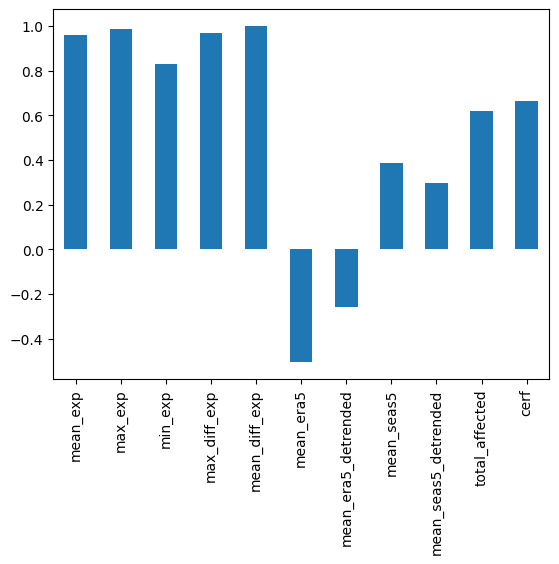

In [244]:
df_compare.set_index("year").corr()["mean_diff_exp"].plot(kind="bar")

<Axes: >

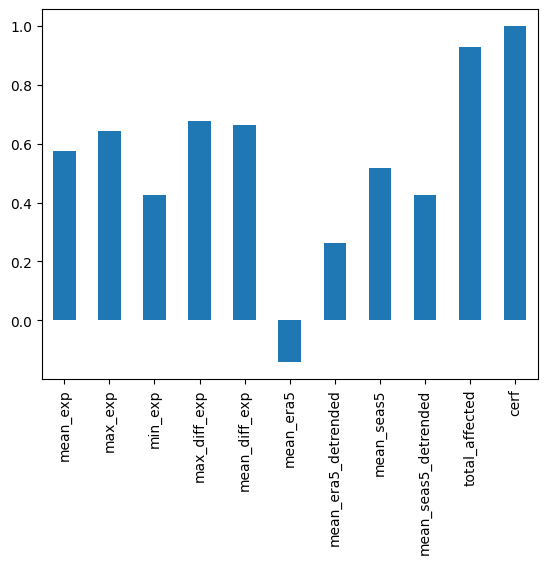

In [245]:
df_compare.set_index("year").corr()["cerf"].plot(kind="bar")

In [246]:
def plot_comparison(df, xcol, ycol, sizecol=None, labels=None):
    df = df.copy()
    fig, ax = plt.subplots(dpi=200, figsize=(7, 7))

    # Replace NaN sizes with a small value
    if sizecol is None:
        sizes = np.full(len(df), 0)
    else:
        sizes = df[sizecol].fillna(0) / df[sizecol].max() * 1000

    # Set colors based on cerf
    df["color"] = df["cerf"].map({True: "crimson", False: "royalblue"})

    scatter = ax.scatter(
        df[xcol], df[ycol], s=sizes, c=df["color"], alpha=0.5, edgecolor="none"
    )

    # Annotate year on each point
    for year, row in df.set_index("year").iterrows():
        ax.annotate(
            str(year),
            (row[xcol], row[ycol]),
            fontsize=8,
            ha="center",
            va="center",
            color=row["color"],
        )

    if labels is None:
        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)
        ax.set_title("")
    else:
        ax.set_xlabel(labels["x"])
        ax.set_ylabel(labels["y"])
        ax.set_title(labels["title"])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return fig, ax

(<Figure size 1400x1400 with 1 Axes>,
 <Axes: title={'center': 'Impact vs. exposure comparison'}, xlabel='Average adjusted flood exposure during year [Floodscan]', ylabel='Total people affected during year [EM-DAT]'>)

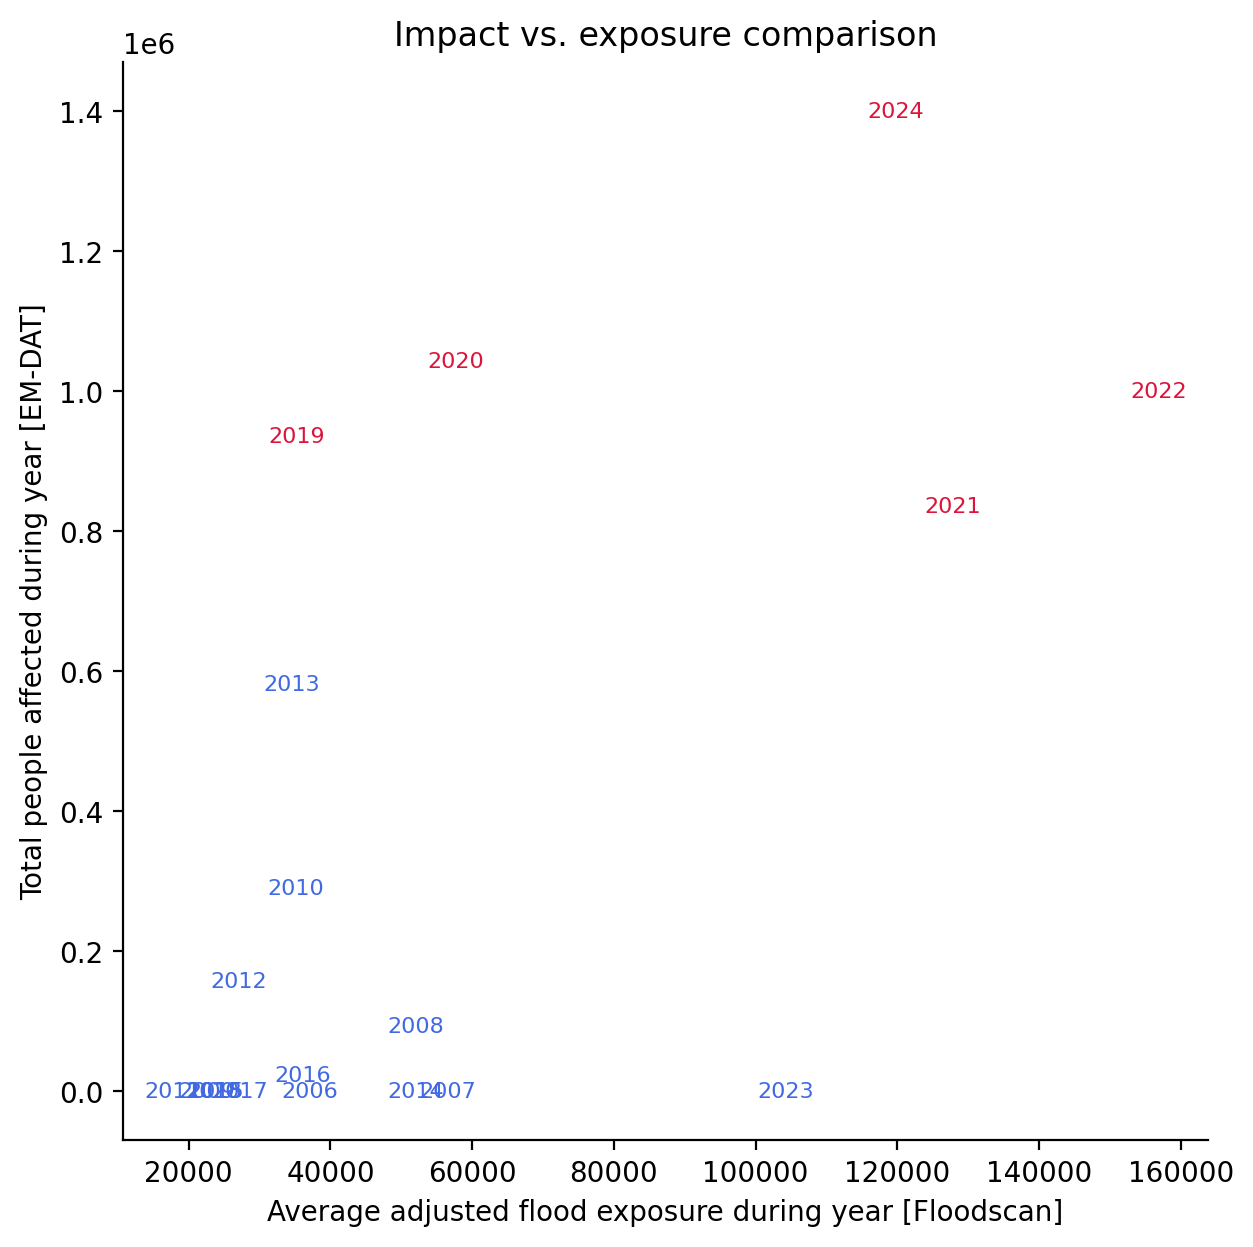

In [247]:
plot_comparison(
    df_compare,
    "mean_diff_exp",
    "total_affected",
    labels={
        "x": "Average adjusted flood exposure during year [Floodscan]",
        "y": "Total people affected during year [EM-DAT]",
        "title": "Impact vs. exposure comparison",
    },
)

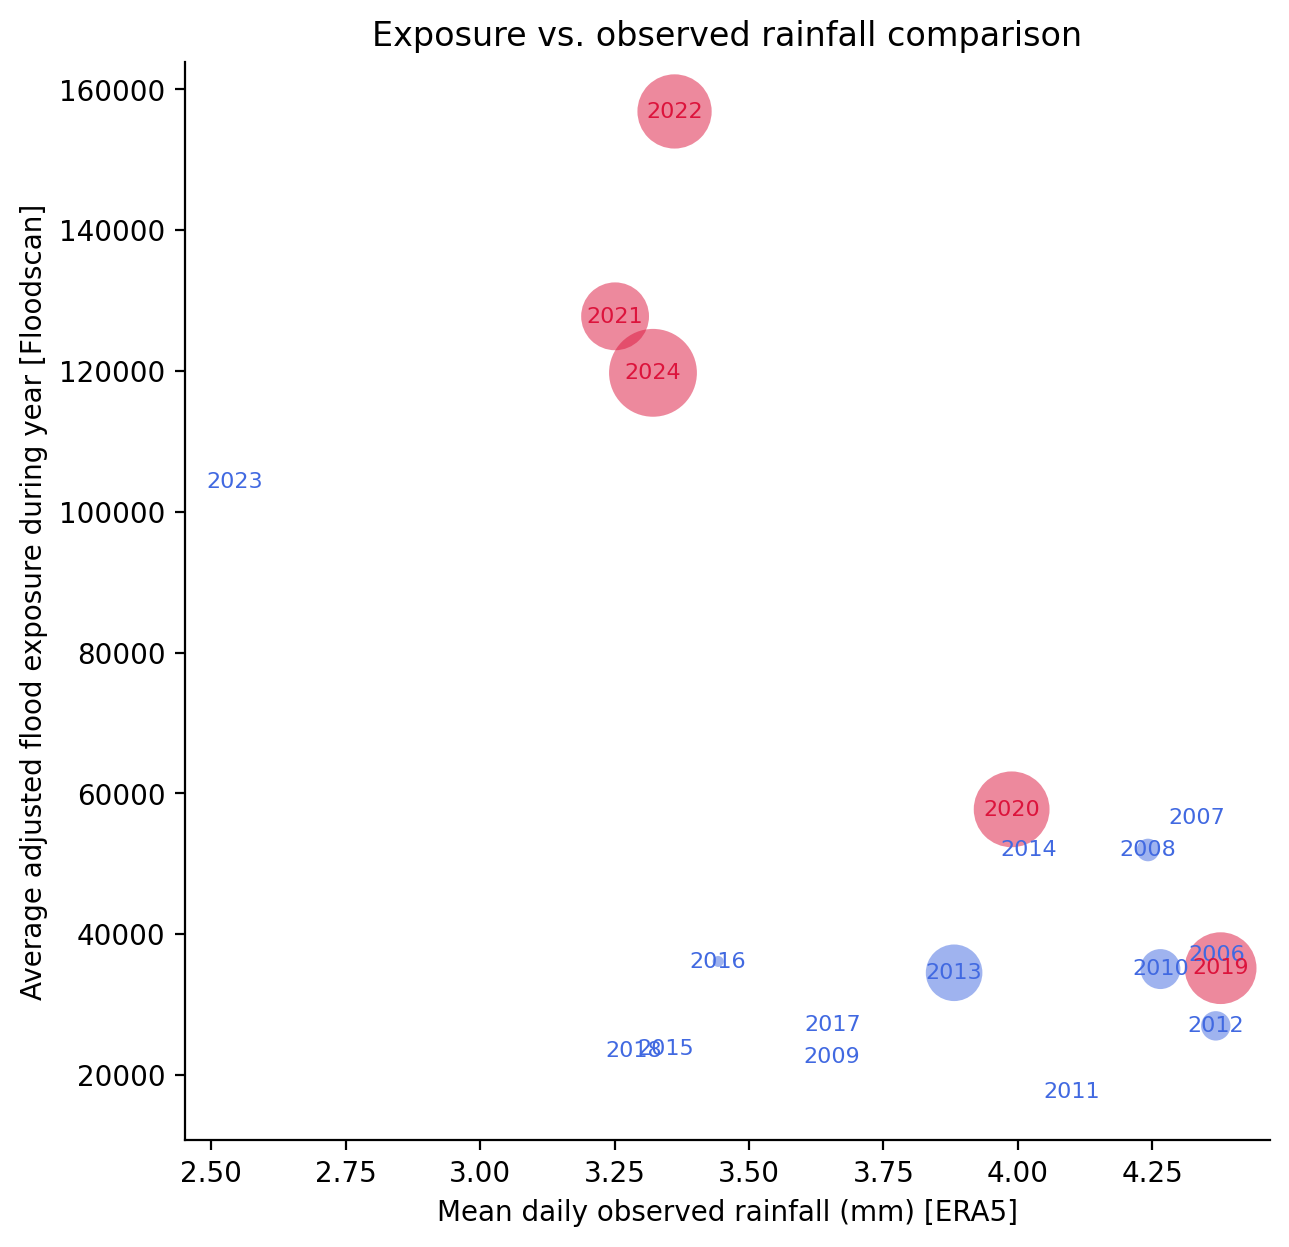

In [248]:
fig, ax = plot_comparison(
    df_compare,
    "mean_era5",
    "mean_diff_exp",
    sizecol="total_affected",
    labels={
        "x": "Mean daily observed rainfall (mm) [ERA5]",
        "y": "Average adjusted flood exposure during year [Floodscan]",
        "title": "Exposure vs. observed rainfall comparison",
    },
)

In [249]:
df_seas5_yearly.set_index("valid_date").loc[2025]["mean"]

np.float64(5.368711057142858)

Text(5.368711057142858, 156878.63287671233, '2025 forecast')

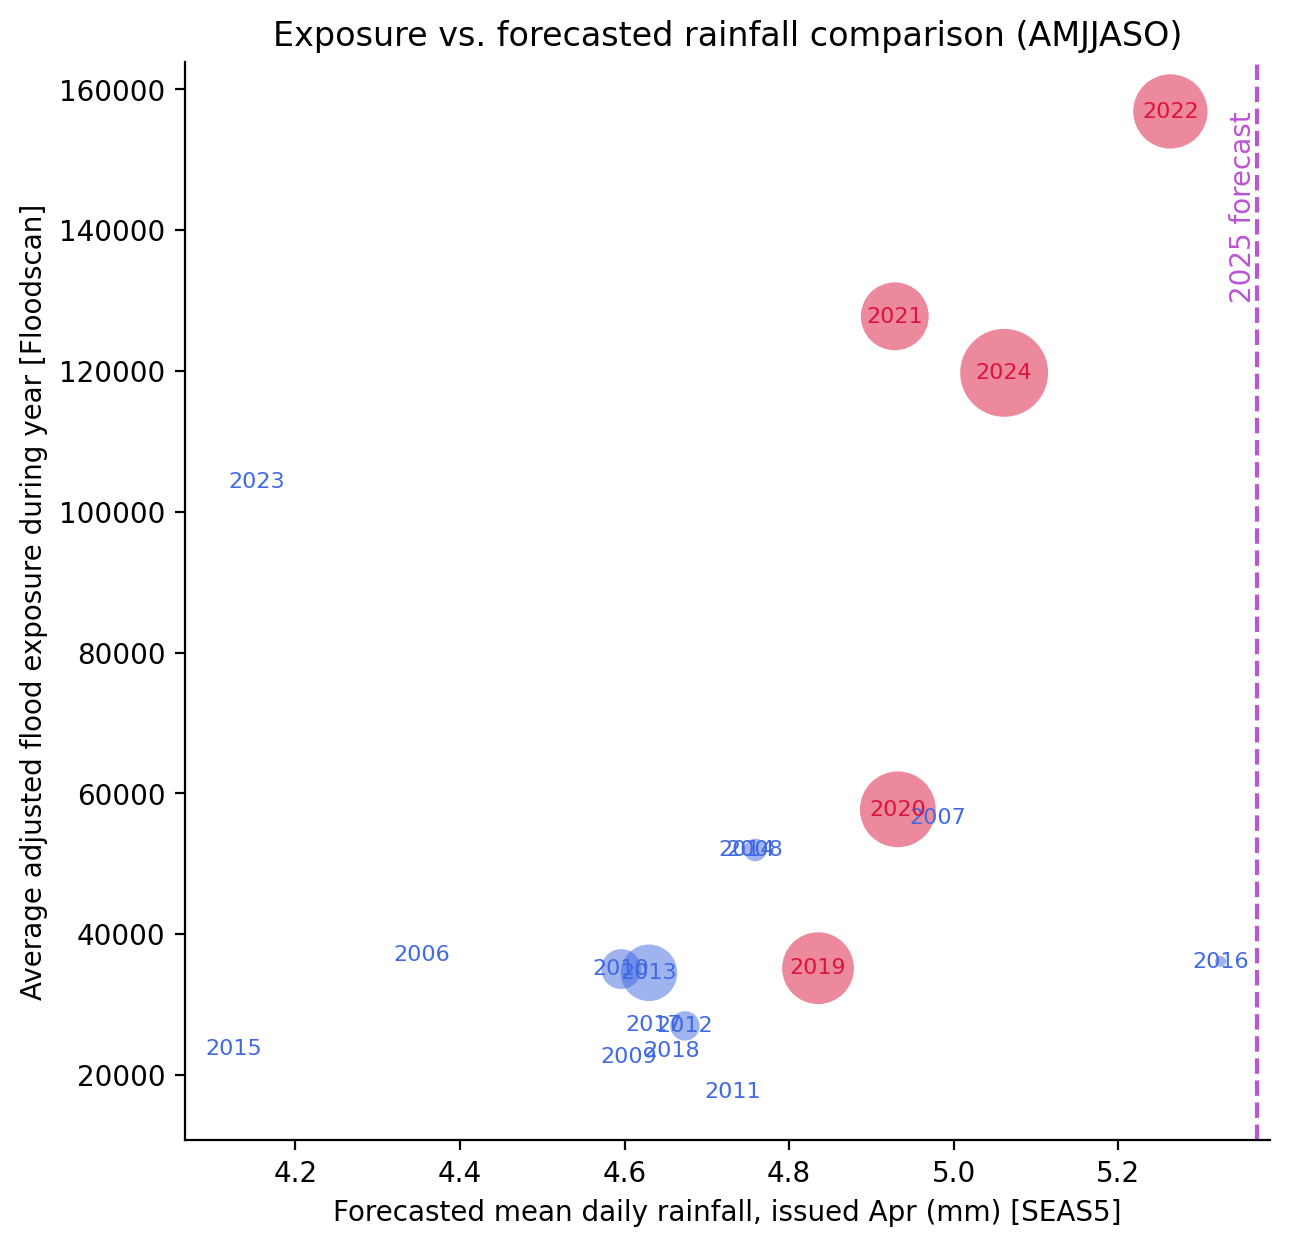

In [250]:
fig, ax = plot_comparison(
    df_compare,
    "mean_seas5",
    "mean_diff_exp",
    sizecol="total_affected",
    labels={
        "x": f"Forecasted mean daily rainfall, issued {issued_mo_str} (mm) [SEAS5]",
        "y": "Average adjusted flood exposure during year [Floodscan]",
        "title": f"Exposure vs. forecasted rainfall comparison ({valid_mo_str})",
    },
)

current_val = df_seas5_yearly.set_index("valid_date").loc[2025]["mean"]

ax.axvline(
    current_val,
    color="mediumorchid",
    linestyle="--",
)
ax.annotate(
    "2025 forecast",
    (current_val, df_compare["mean_diff_exp"].max()),
    rotation=90,
    va="top",
    ha="right",
    color="mediumorchid",
)

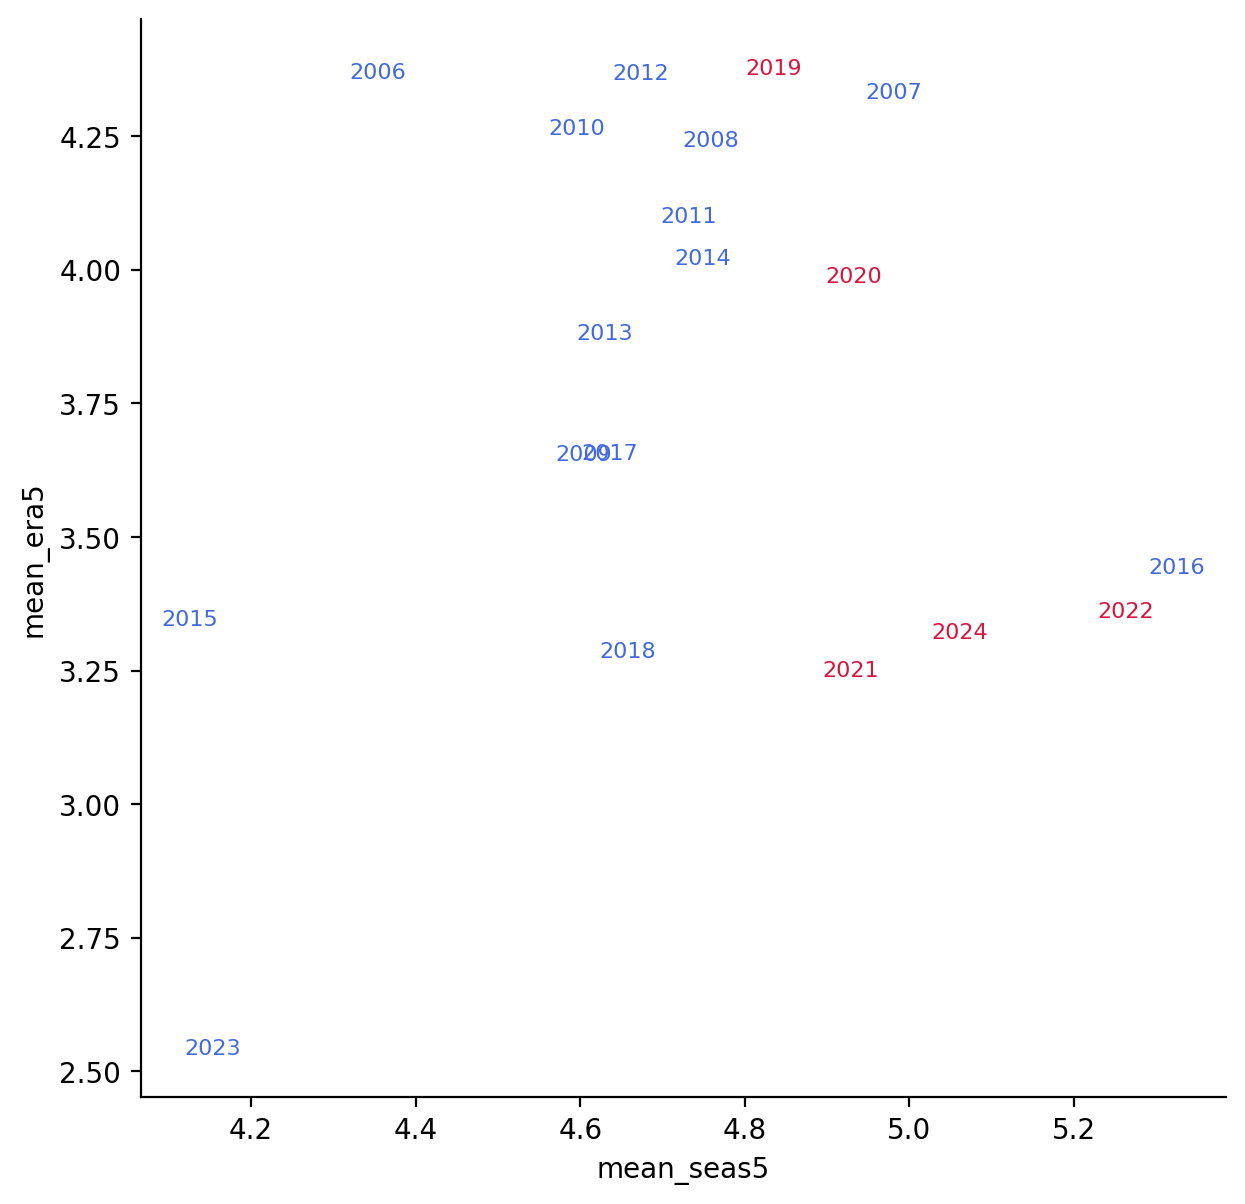

In [251]:
fig, ax = plot_comparison(
    df_compare,
    "mean_seas5",
    "mean_era5",
)

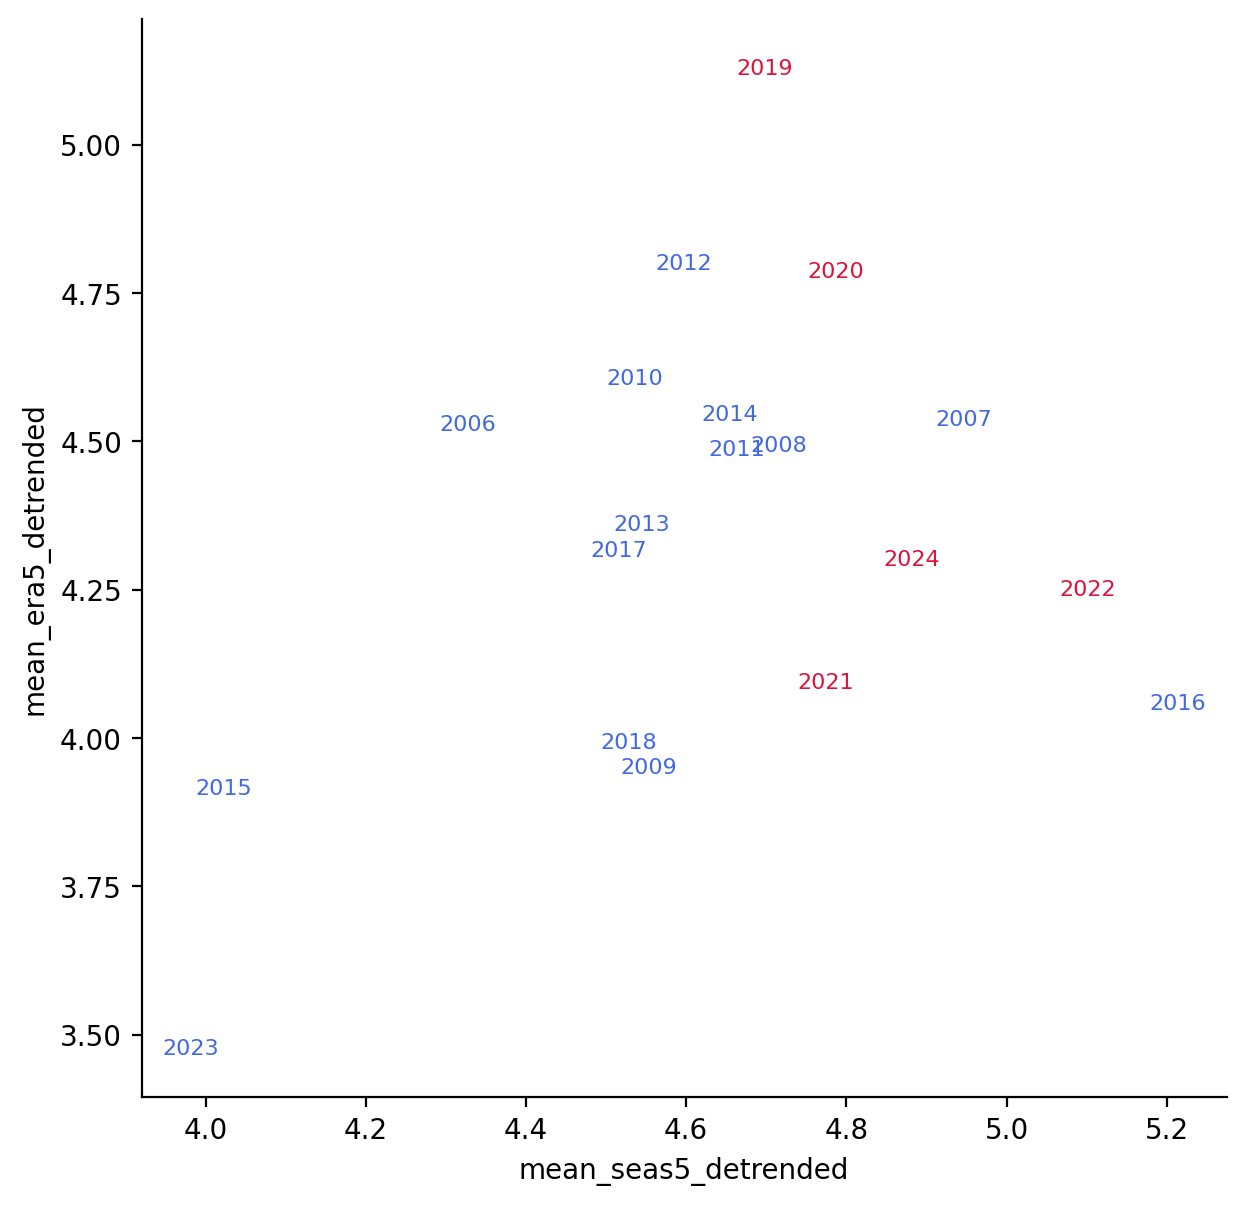

In [252]:
fig, ax = plot_comparison(
    df_compare,
    "mean_seas5_detrended",
    "mean_era5_detrended",
)